<a href="https://colab.research.google.com/github/aathil28/CDC_Diabetes_Health_Indicators_Preprocessing_Dataset/blob/feature%2FEDA/CDC_Diabetes_Preprocessing_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Clone Git Repo
# ***************
!git clone 'https://github.com/aathil28/CDC_Diabetes_Health_Indicators_Preprocessing_Dataset'

Cloning into 'CDC_Diabetes_Health_Indicators_Preprocessing_Dataset'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 52 (delta 24), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 3.88 MiB | 2.65 MiB/s, done.
Resolving deltas: 100% (24/24), done.


# Libraries

##Loading Libraries

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import BaggingClassifier

# for decision tree
from sklearn.tree import DecisionTreeClassifier

# for knn
from sklearn.neighbors import KNeighborsClassifier

# Reading data

In [4]:
# # Mounting Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# Reading Dataset
filepath = '/content/CDC_Diabetes_Health_Indicators_Preprocessing_Dataset/diabetes_012_health_indicators_BRFSS2015.csv'
df_cdc = pd.read_csv(filepath)
df_cdc.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


# EDA (Exploratory Data Analysis)

In [6]:
df_cdc.info()
# This shows
# number of rows
# number of columns
# column names
# how many non-null values each column has
# each column’s data type
# memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
df_cdc.describe() # This shows the Values, Ranges, Spread

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [8]:
df_cdc.shape # This shows the size of the DataFrame

(253680, 22)

In [9]:
df_cdc.columns # This shows the names of columns the DataFrame

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [10]:
df_cdc.isna() # This checks for missing values

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
253676,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
253677,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
253678,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
df_cdc.isna().sum() # This checks sum of missing values in each column

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [12]:
for i in df_cdc.columns: # This means for each columns in df_cdc, 'basically a loop'
  print('Columns :',i)   # This prints the column names
  print(df_cdc[i].unique()) # This prints the unique values in each columns

Columns : Diabetes_012
[0. 2. 1.]
Columns : HighBP
[1. 0.]
Columns : HighChol
[1. 0.]
Columns : CholCheck
[1. 0.]
Columns : BMI
[40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Columns : Smoker
[1. 0.]
Columns : Stroke
[0. 1.]
Columns : HeartDiseaseorAttack
[0. 1.]
Columns : PhysActivity
[0. 1.]
Columns : Fruits
[0. 1.]
Columns : Veggies
[1. 0.]
Columns : HvyAlcoholConsump
[0. 1.]
Columns : AnyHealthcare
[1. 0.]
Columns : NoDocbcCost
[0. 1.]
Columns : GenHlth
[5. 3. 2. 4. 1.]
Columns : MentHlth
[18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
Columns : PhysHlth
[15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19. 

In [13]:
for i in df_cdc.columns: # This means for each columns in df_cdc, 'basically a loop'
  print('Columns :',i)   # This prints the column names
  print(df_cdc[i].value_counts()) # This prints the values counts in each columns

Columns : Diabetes_012
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64
Columns : HighBP
HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64
Columns : HighChol
HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64
Columns : CholCheck
CholCheck
1.0    244210
0.0      9470
Name: count, dtype: int64
Columns : BMI
BMI
27.0    24606
26.0    20562
24.0    19550
25.0    17146
28.0    16545
        ...  
85.0        1
86.0        1
91.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64
Columns : Smoker
Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64
Columns : Stroke
Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64
Columns : HeartDiseaseorAttack
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64
Columns : PhysActivity
PhysActivity
1.0    191920
0.0     61760
Name: count, dtype: int64
Columns : Fruits
Fruits
1.0    160898
0.0     92782
Name: count, dtype: int64
Columns : Ve

##Histogram

In [14]:
non_cat = ['BMI', 'MentHlth', 'PhysHlth']
non_cat

['BMI', 'MentHlth', 'PhysHlth']

[]

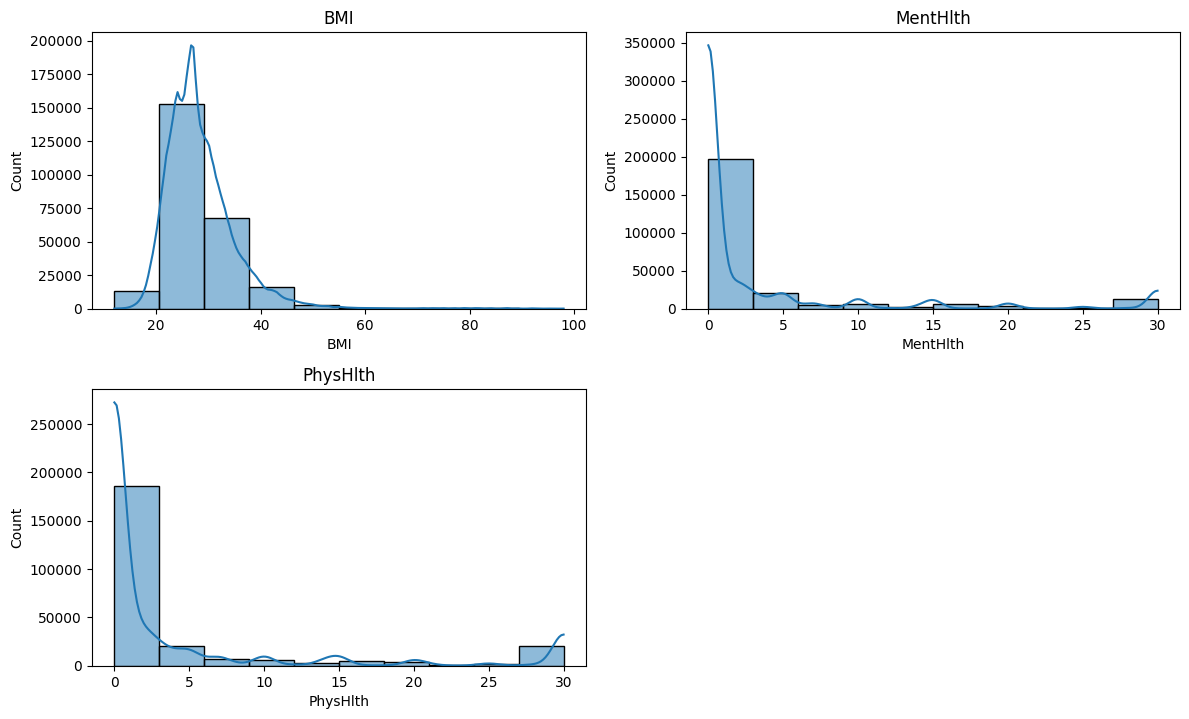

In [15]:
plt.figure(figsize = (12,14))
for i , column in enumerate(non_cat, 1):
  plt.subplot(4,2,i)
  sns.histplot(df_cdc[column], kde = True, bins = 10)
  plt.title(column)
  plt.xlabel(column)
plt.tight_layout()
plt.plot()


In [16]:
# Checking skewness
for col in non_cat:
    print(f"\nColumn: {col}")
    print(df_cdc[col].skew())


Column: BMI
2.122003758291108

Column: MentHlth
2.721148365662696

Column: PhysHlth
2.2073949151986723


In [17]:
# BMI, MentHlth, and PhysHlth histogram shows they are right skewed

#Preprocessing

##Data Cleaning

###Missing Value analysis

In [18]:
# No missing values in the data set

### Outlier Management

#### Creating boxplots

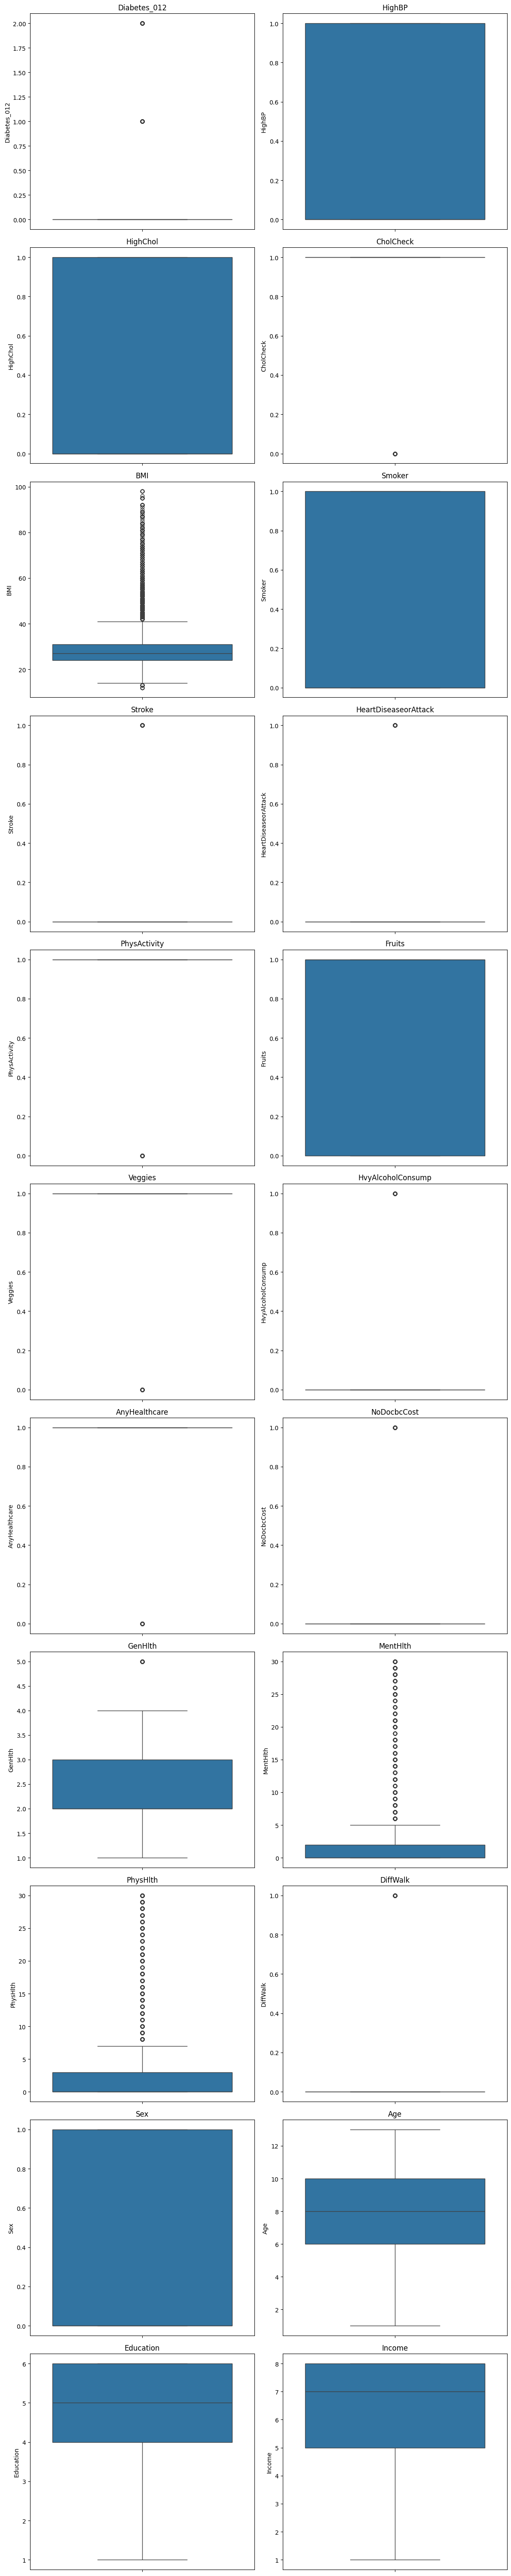

In [19]:
plt.figure(figsize= (12, 60))
i= 1

for column in df_cdc:
  plt.subplot(11,2,i)
  sns.boxplot(df_cdc[column])
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

checking the amount of outliers

In [20]:
for column in df_cdc :
  Q1 = df_cdc[column].quantile(0.25)
  Q3 = df_cdc[column].quantile(0.75)

  IQR = Q3- Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR
  Outliers = df_cdc[column][(df_cdc[column]< lower) | (df_cdc[column] > upper)]

  print("Column :", column)
  print("Q1 :",Q1)
  print("Q3 :",Q3)
  print("IQR :",IQR)
  print("Number of outliers:" ,len(Outliers))


Column : Diabetes_012
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of outliers: 39977
Column : HighBP
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Number of outliers: 0
Column : HighChol
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Number of outliers: 0
Column : CholCheck
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Number of outliers: 9470
Column : BMI
Q1 : 24.0
Q3 : 31.0
IQR : 7.0
Number of outliers: 9847
Column : Smoker
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Number of outliers: 0
Column : Stroke
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of outliers: 10292
Column : HeartDiseaseorAttack
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of outliers: 23893
Column : PhysActivity
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Number of outliers: 61760
Column : Fruits
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Number of outliers: 0
Column : Veggies
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Number of outliers: 47839
Column : HvyAlcoholConsump
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of outliers: 14256
Column : AnyHealthcare
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Number of outliers: 12417
Column : NoDocbcCost
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of 

No outliers detected by IQR method is removed as IQR method are within the possible range of values.

### Duplicate's Management

In [21]:
df_cdc.duplicated().sum()

np.int64(23899)

In [22]:
# calculating the percentage of duplicate entries

perc_duplicate = ((df_cdc.duplicated().sum())/len(df_cdc))*100
perc_duplicate

#9.420 % of the observations are duplicates. Hence removing it

np.float64(9.42092399873857)

In [23]:
df_cdc.drop_duplicates(inplace =True)
len(df_cdc)

#

229781

###Correlation Analysis

In [24]:
corr_matrix = df_cdc.corr()
corr_matrix

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_012,1.000000,0.261976,0.203327,0.075701,0.212027,0.046774,0.100276,0.170816,-0.103408,-0.025462,...,0.024911,0.023568,0.284881,0.057698,0.160485,0.210638,0.032243,0.184642,-0.107742,-0.147102
HighBP,0.261976,1.000000,0.284186,0.111220,0.194126,0.074237,0.124426,0.201271,-0.104131,-0.019329,...,0.052084,0.002216,0.272562,0.037374,0.144413,0.211498,0.047155,0.339808,-0.112676,-0.139782
HighChol,0.203327,0.284186,1.000000,0.094753,0.089615,0.074627,0.089258,0.176279,-0.063266,-0.026125,...,0.052412,0.002900,0.187929,0.050212,0.110801,0.135826,0.022894,0.263866,-0.049838,-0.061871
CholCheck,0.075701,0.111220,0.094753,1.000000,0.042420,-0.003776,0.027894,0.049995,-0.004409,0.017973,...,0.115539,-0.054198,0.062782,-0.001549,0.040612,0.048969,-0.024255,0.095996,-0.009758,0.002161
BMI,0.212027,0.194126,0.089615,0.042420,1.000000,-0.009196,0.011062,0.039926,-0.127864,-0.067528,...,-0.008560,0.045837,0.208411,0.068653,0.102844,0.182604,0.030989,-0.049347,-0.074568,-0.069192
Smoker,0.046774,0.074237,0.074627,-0.003776,-0.009196,1.000000,0.054438,0.105154,-0.066981,-0.061947,...,-0.013983,0.037353,0.134979,0.077715,0.100514,0.108179,0.096709,0.107653,-0.135793,-0.095418
Stroke,0.100276,0.124426,0.089258,0.027894,0.011062,0.054438,1.000000,0.198863,-0.059440,-0.004613,...,0.013565,0.028691,0.169870,0.062111,0.140919,0.169442,0.003560,0.128040,-0.064319,-0.117232
HeartDiseaseorAttack,0.170816,0.201271,0.176279,0.049995,0.039926,0.105154,0.198863,1.000000,-0.073267,-0.007128,...,0.025899,0.022076,0.246411,0.052756,0.170473,0.202779,0.089717,0.223626,-0.082466,-0.122908
PhysActivity,-0.103408,-0.104131,-0.063266,-0.004409,-0.127864,-0.066981,-0.059440,-0.073267,1.000000,0.125283,...,0.024095,-0.046620,-0.237676,-0.106175,-0.199562,-0.235943,0.033586,-0.087539,0.171224,0.166171
Fruits,-0.025462,-0.019329,-0.026125,0.017973,-0.067528,-0.061947,-0.004613,-0.007128,0.125283,1.000000,...,0.022756,-0.032521,-0.071433,-0.052409,-0.024744,-0.030188,-0.088628,0.073726,0.085174,0.051230


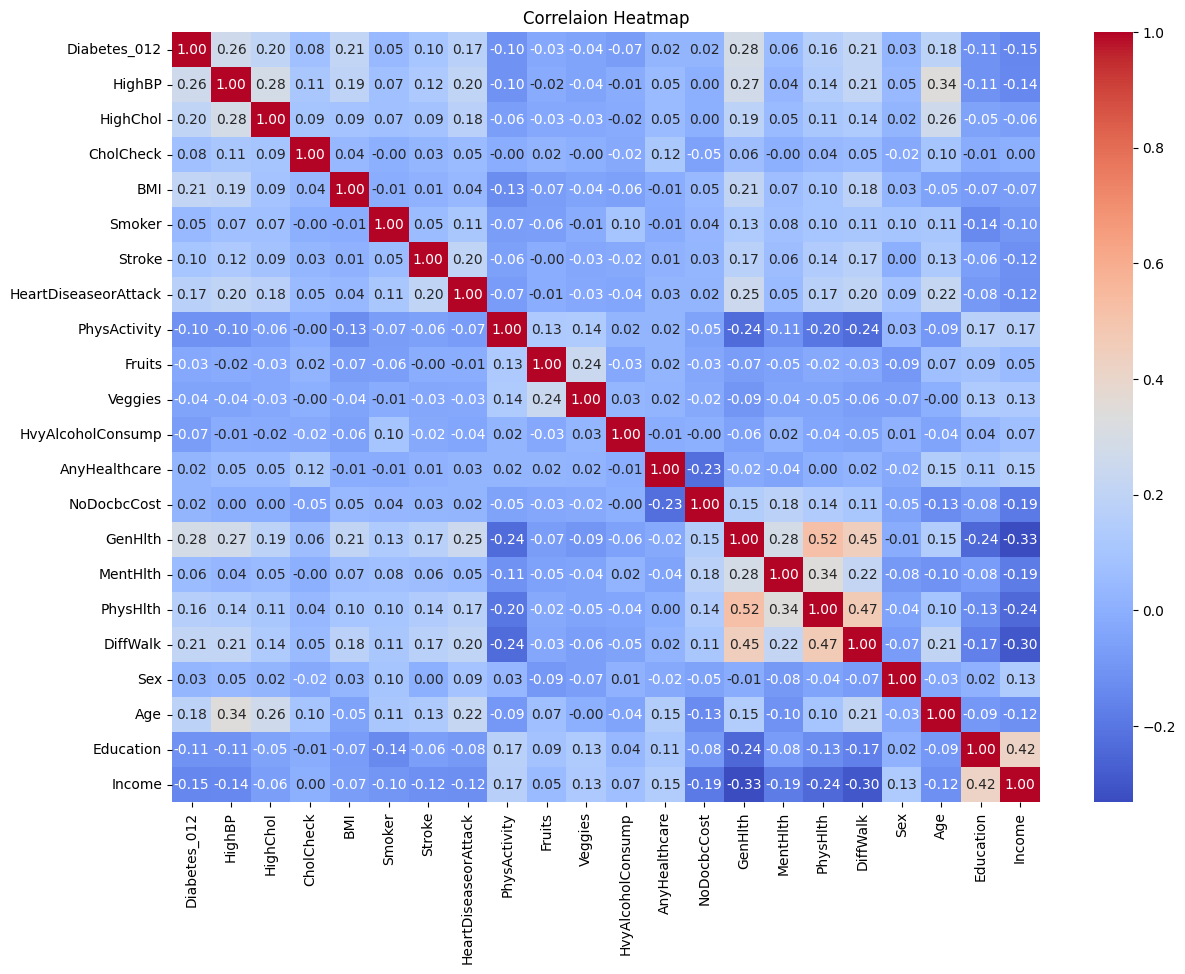

In [25]:
#plotting correlation heatmap
plt.figure(figsize = (14,10)) # width and height of the map
sns.heatmap(corr_matrix,
            annot = True,
            cmap = "coolwarm",
            fmt = ".2f") # display 2 decimal places
plt.title("Correlaion Heatmap")
plt.show()

In [26]:
# correlation of feature wrt target
corr_target = df_cdc.corr()["Diabetes_012"]
# sort in ascending order
corr_target.sort_values(ascending = True)

,Diabetes_012
Income,-0.147102
Education,-0.107742
PhysActivity,-0.103408
HvyAlcoholConsump,-0.067164
Veggies,-0.043446
Fruits,-0.025462
NoDocbcCost,0.023568
AnyHealthcare,0.024911
Sex,0.032243
Smoker,0.046774


##Data Transforming

###Scaling

In [27]:
# Before scaling
df_cdc.head(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [28]:
# Scaling the continuous numerical column
# For skewed we use MinMaxScaler, since histogram of BHI is right skewed
min_max_scaler = MinMaxScaler()
skew_cols = ['BMI']

df_cdc[skew_cols] = min_max_scaler.fit_transform(df_cdc[skew_cols])

In [29]:
# After scaling
df_cdc.head(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,0.325581,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,0.151163,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,0.186047,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,0.174419,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,0.139535,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


###Encoding

In [30]:
# Inference : No additional encoding was performed because all categorical variables in the dataset were already numerically encoded.

##Mutual Information Analysis

In [31]:
X = df_cdc.drop(columns=["Diabetes_012"])
y = df_cdc["Diabetes_012"]
mi = mutual_info_classif(X, y, random_state = 42)
#convert mi into dataframe
mi_df = pd.DataFrame({"Features" : X.columns, "Mutual Information" :mi })
mi_df


,Features,Mutual Information
0,HighBP,0.053703
1,HighChol,0.038094
2,CholCheck,0.044068
3,BMI,0.030561
4,Smoker,0.024138
5,Stroke,0.003137
6,HeartDiseaseorAttack,0.011853
7,PhysActivity,0.043884
8,Fruits,0.031857
9,Veggies,0.034996


#Model Building

In [32]:
df_cdc.info

<bound method DataFrame.info of         Diabetes_012  HighBP  HighChol  CholCheck       BMI  Smoker  Stroke  \
0                0.0     1.0       1.0        1.0  0.325581     1.0     0.0   
1                0.0     0.0       0.0        0.0  0.151163     1.0     0.0   
2                0.0     1.0       1.0        1.0  0.186047     0.0     0.0   
3                0.0     1.0       0.0        1.0  0.174419     0.0     0.0   
4                0.0     1.0       1.0        1.0  0.139535     0.0     0.0   
...              ...     ...       ...        ...       ...     ...     ...   
253675           0.0     1.0       1.0        1.0  0.383721     0.0     0.0   
253676           2.0     1.0       1.0        1.0  0.069767     0.0     0.0   
253677           0.0     0.0       0.0        1.0  0.186047     0.0     0.0   
253678           0.0     1.0       0.0        1.0  0.127907     0.0     0.0   
253679           2.0     1.0       1.0        1.0  0.151163     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                        0.0           0.0     0.0  ...            1.0   
1                        0.0           1.0     0.0  ...            0.0   
2                        0.0           0.0     1.0  ...            1.0   
3                        0.0           1.0     1.0  ...            1.0   
4                        0.0           1.0     1.0  ...            1.0   
...                      ...           ...     ...  ...            ...   
253675                   0.0           0.0     1.0  ...            1.0   
253676                   0.0           0.0     0.0  ...            1.0   
253677                   0.0           1.0     1.0  ...            1.0   
253678                   0.0           0.0     1.0  ...            1.0   
253679                   1.0           1.0     1.0  ...            1.0   

        NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  \
0               0.0      5.0      18.0      15.0       1.0  0.0   9.0   
1               1.0      3.0       0.0       0.0       0.0  0.0   7.0   
2               1.0      5.0      30.0      30.0       1.0  0.0   9.0   
3               0.0      2.0       0.0       0.0       0.0  0.0  11.0   
4               0.0      2.0       3.0       0.0       0.0  0.0  11.0   
...             ...      ...       ...       ...       ...  ...   ...   
253675          0.0      3.0       0.0       5.0       0.0  1.0   5.0   
253676          0.0      4.0       0.0       0.0       1.0  0.0  11.0   
253677          0.0      1.0       0.0       0.0       0.0  0.0   2.0   
253678          0.0      3.0       0.0       0.0       0.0  1.0   7.0   
253679          0.0      2.0       0.0       0.0       0.0  0.0   9.0   

        Education  Income  
0             4.0     3.0  
1             6.0     1.0  
2             4.0     8.0  
3             3.0     6.0  
4             5.0     4.0  
...           ...     ...  
253675        6.0     7.0  
253676        2.0     4.0  
253677        5.0     2.0  
253678        5.0     1.0  
253679        6.0     2.0  

[229781 rows x 22 columns]>

##Train Test Split

In [33]:
# split into test and train

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=33)

##Logistic Regression

In [34]:
# create model object
log_reg = LogisticRegression()

# Train the model
log_reg.fit(X_train, y_train)

# predictions using the model
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate model preformance
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg, average = 'weighted')
recall_log_reg = recall_score(y_test, y_pred_log_reg, average = 'weighted')
f1_scor_log_reg = f1_score(y_test, y_pred_log_reg, average = 'weighted')

print(' Logistic Regression Accuracy is :', acc_log_reg)
print(' Logistic Regression precision_score is :', precision_log_reg)
print(' Logistic Regression recall_score is :', recall_log_reg)
print(' Logistic Regression f1_score is :', f1_scor_log_reg)

# We are using 'average = weighted' since the target is multiclass (0. , 1., 2.)
# The Logistic Regression model provides an accuracy of '83.11%'

 Logistic Regression Accuracy is : 0.8311247470461518
 Logistic Regression precision_score is : 0.7791917184932137
 Logistic Regression recall_score is : 0.8311247470461518
 Logistic Regression f1_score is : 0.7881093015763242


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###Cross Validation

#### K-fold cross validation

In [35]:
kf_obj  = KFold(n_splits = 5, shuffle = True)

# Case of Logistic Regression
scores = cross_val_score(LogisticRegression(), X_train, y_train, cv = kf_obj)
print('For Logistic Regression')
print('cross validation score:',scores)
print("mean of cv scores:", scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

For Logistic Regression
cross validation score: [0.83087175 0.83217734 0.82956616 0.83032776 0.82918072]
mean of cv scores: 0.8304247473451394


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
# For Logistic Regression
# cross validation score: [0.83051816 0.83166055 0.83057256 0.82926697 0.82945273]
# mean of cv scores: 0.8302941898693078

#### Grid search cross validation

In [37]:
para_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs'],
    'max_iter': [500]
}

In [38]:
# create model object
grid = GridSearchCV(LogisticRegression(), para_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)

# Train the model
grid.fit(X_train, y_train)
print('best parameters are :', grid.best_params_)
print('Best score:', grid.best_score_)



best parameters are : {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
Best score: 0.8317901990610646


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
# GridSearchCV
# best parameters are : {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
# Best score: 0.8317901990610646

#### Random search cross validation

In [40]:
random_search = RandomizedSearchCV(LogisticRegression(),para_grid,cv=5,scoring='accuracy',n_jobs=-1
)
random_search.fit(X_train, y_train)
2
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'solver': 'lbfgs', 'max_iter': 500, 'C': 1}
Best Score: 0.8317901990610646


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
# RandomizedSearchCV
# Best Parameters: {'solver': 'lbfgs', 'max_iter': 500, 'C': 1}
# Best Score: 0.8317901990610646

In [42]:
# Building a model after comparing GridSearchCV and RandomizedSearchCV
# But both are having exact accuracy, therefore choosing GridSearchCV randomly

# Using GridSerachCV
LR_best_model = grid.best_estimator_

# Train the model
LR_best_model.fit(X_train, y_train)

# Predict using model
LR_best_model_y_pred = LR_best_model.predict(X_test)

# Evaluating
accuracy = accuracy_score(y_test, LR_best_model_y_pred)
print("Test Accuracy:", accuracy)

# Test Accuracy: 0.831124747046151

Test Accuracy: 0.8311247470461518


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Ensemble Model - Bagging Classifier

In [43]:
# create model object
bag_class = BaggingClassifier(estimator = LogisticRegression(), n_estimators = 8, max_samples = 0.6, )

# Train the model
bag_class.fit(X_train, y_train)

# predictions using the model
y_pred_bag_class = bag_class.predict(X_test)

# Evaluate model preformance
acc_bag_class = accuracy_score(y_test, y_pred_bag_class)

print('Bagging Accuracy is :', acc_bag_class)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Bagging Accuracy is : 0.8311465065169615


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
# Bagging Accuracy is : 0.8310377091629132

# Decision Tree Classification

## Decision Tree base model

In [45]:
# creating the model object
dt_model = DecisionTreeClassifier()
# fitting
dt_model.fit(X_train,y_train)
# prediction
y_pred_dt = dt_model.predict(X_test)
# evaluation
acc_dt = accuracy_score(y_test,y_pred_dt)
acc_dt


0.7415845246643602

In [46]:
prec_dt = precision_score(y_test,y_pred_dt, average = 'weighted')
# using weigthed average as it is a multiclass classification problem ,
# hence weighted average of all class frequencies is utilised
prec_dt

0.7591639459389941

In [47]:
rec_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("Accuracy :", acc_dt)
print("Precision:", prec_dt)
print("Recall   :", rec_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.7415845246643602
Precision: 0.7591639459389941
Recall   : 0.7415845246643602
F1 Score : 0.7500047116806362


In [48]:
# model correctly classifies 74% of the observations.
# precison of the decision tree model is 0.75, showing that 75% On average, predictions for each class are correct

In [49]:
print("Depth of tree:", dt_model.get_depth())
print("Number of nodes:", dt_model.tree_.node_count)
print("Number of leaves:", dt_model.get_n_leaves())

Depth of tree: 39
Number of nodes: 84903
Number of leaves: 42452


## Cross Validation

### 1. K fold cross validation

In [50]:
# built the obj
kf_obj =KFold()
# train the model
scores_dt = cross_val_score(DecisionTreeClassifier(),X_train,y_train,cv = kf_obj)
print("For decision tree model")
print("cross validation scores" ,scores_dt)
# the difference in cross validation scores can be used for understanding the variance of the data
#
print("mean of cross validation scores" ,scores_dt.mean())
print("******")

For decision tree model
cross validation scores [0.74290766 0.7378485  0.7377397  0.7378213  0.74290066]
mean of cross validation scores 0.7398435626311095
******


### 2. Gridsearch

In [51]:
param_grid = {'criterion': ['gini','entropy'],
             'max_depth': [2, 3, 4, 5, 6,39],
             'min_samples_split': [2, 4, 6,25]}

# built the model obj
grid = GridSearchCV(DecisionTreeClassifier(),param_grid, cv =5, scoring = 'accuracy') # 'accuracy' - training accuracy
# train the model
grid.fit(X_train,y_train)
print("best parameters are : ", grid.best_params_)
print("best accuracy is : ", grid.best_score_)

# based on the parameter got by drid search, crating a decision tree , which is a hyperparameter tuning

dt_model_grid = DecisionTreeClassifier(criterion= "entropy",max_depth = 5, min_samples_split= 2)
#train the model
dt_model_grid.fit(X_train,y_train)
# making the predictions
y_pred_grid = dt_model_grid.predict(X_test)
acc_dt_grid = accuracy_score(y_test, y_pred_grid)
acc_dt_grid

best parameters are :  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
best accuracy is :  0.8330087502004803


0.8328872641817351

### 3. RandomSearch

In [52]:
random_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_grid,
    n_iter=10,          # Number of random combinations to try
    cv=5,               # 5-fold cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# fitting the model
random_search.fit(X_train, y_train)

# printing the best parameters
print(random_search.best_params_)
print(random_search.best_score_)

#View the best cross-validation score
best_model = random_search.best_estimator_

# Make predictions using the best model
y_pred_rcv = best_model.predict(X_test)
acc_rcv =  accuracy_score(y_test, y_pred_rcv)
print("Accuracy:", acc_rcv)

{'min_samples_split': 4, 'max_depth': 5, 'criterion': 'entropy'}
0.8330087502004803
Accuracy: 0.8328872641817351


## Ensemble models- Decision Tree


In [53]:
# applying bagging
from sklearn.ensemble import BaggingClassifier
# applying boosting
from sklearn.ensemble import AdaBoostClassifier

In [54]:
### 1. Bagging

In [55]:
bagging_model = BaggingClassifier(
    estimator = DecisionTreeClassifier(), # DecisionTreeClassifier for model creation
    n_estimators = 60, # num. of models need to be created
    max_samples =0.7 # ensuring 60% of original sample is randolmly selected
)

bagging_model.fit(X_train,y_train)
y_pred_bag = bagging_model.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)
acc_bag

0.8202232521705072

# KNN Classification

## KNN Base Model

In [59]:
# ACCURACY, PRECISION, RECALL, F1 SCORE

# Build model object
knn_obj = KNeighborsClassifier(n_neighbors=4)

# Train model
knn_obj.fit(X_train, y_train)

# Make predictions using the model
y_pred_knn = knn_obj.predict(X_test)

# Evaluate model performance
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average= 'weighted')
knn_recall = recall_score(y_test, y_pred_knn, average= 'weighted')
knn_f1_score = f1_score(y_test, y_pred_knn, average= 'weighted')

print('KNN_ACCURACY :',knn_accuracy)
print('KNN_PRECISION :',knn_precision)
print('KNN_RECALL :',knn_recall)
print('F1 SCORE :',knn_f1_score)

KNN_ACCURACY : 0.8181343429727789
KNN_PRECISION : 0.7555983669385766
KNN_RECALL : 0.8181343429727789
F1 SCORE : 0.7731662951029862


##Cross Validation



###K-Fold

In [60]:
kf_obj = KFold(n_splits = 5,shuffle = True)
scores = cross_val_score(KNeighborsClassifier(),X_train, y_train, cv = kf_obj)

print('For KNN Model')
print('Cross validation scores : ', scores)
print('Mean of cv scores : ', scores.mean())

For KNN Model
Cross validation scores :  [0.81068951 0.80777914 0.81419829 0.81504148 0.81035796]
Mean of cv scores :  0.8116132754410927


###Grid Search CV

In [61]:
# Define the parameter youwant to check
para_grid = {
    'n_neighbors': [3, 5],
    'weights': ['distance'],
    'metric': ['euclidean']
    }

# Build the model object
grid = GridSearchCV(KNeighborsClassifier(),
                    para_grid, cv = 3, scoring = 'accuracy', n_jobs=-1)

# Train the nmodel
grid.fit(X_train, y_train)
print('best parameters are : ',grid.best_params_)
print('best cross validation score : ' , grid.best_score_)

best parameters are :  {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
best cross validation score :  0.7970613207539422


###Random search

In [62]:
random_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=para_grid,
    cv=3,               # 3-fold cross-validation
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best cross-validation F1 score:", random_search.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'euclidean'}
Best cross-validation F1 score: 0.7970613207539422


##Ensemble Models - Bagging

In [ ]:
# Build model object
bagging_model = BaggingClassifier(
      estimator = KNeighborsClassifier(),
      n_estimators = 8,
      max_samples = 0.6
      )

# Train model
bagging_model.fit(X_train, y_train)

# Make predictions using the model
y_pred_bag = bagging_model.predict(X_test)

# Evaluate model performance
acc_bag = accuracy_score(y_test, y_pred_bag)

In [64]:
print('Bagging model accuracy:', acc_bag)

Bagging model accuracy: 0.8189829623343561


#Model Comparison

In [65]:

print("MODEL COMPARISON")
print('***********************')
print('\n')

print('LOGISTIC REGRESSION')
print('***********************')
print(f"Logistic Regression Accuracy      : {acc_log_reg:.4f}")
print(f"Logistic Regression Precision     : {precision_log_reg:.4f}")
print(f"Logistic Regression Recall        : {recall_log_reg:.4f}")
print(f"Logistic Regression F1-Score      : {f1_scor_log_reg:.4f}")
print('\n')
print("CROSS VALIDATION OF THE LOGISTIC REGRESSION")
print('***********************')
print(f"K-Fold CV Mean Accuracy : {scores.mean():.4f}")

print(f"GridSearchCV Best Accuracy: {grid.best_score_:.4f}")

print(f"RandomizedSearchCV Best Accuracy: {random_search.best_score_:.4f}")
print('\n')

print("ENSEMBLE MODEL- LOGISTIC REGRESSION")
print('***********************')
print(f"Bagging Accuracy: {acc_bag_class:.4f}")
print('\n')

print("DECISION TREE CLASSIFICATION")
print("***********************")
print("\n")
print("DECISION TREE- Base model")
print("***********************")
print(f"Decision Tree Accuracy      : {acc_dt:.4f}")
print(f"Decision Tree Precision     : {prec_dt:.4f}")
print(f"Decision Tree Recall        : {rec_dt:.4f}")
print(f"Decision Tree F1-Score      : {f1_dt:.4f}")
print("\n")

print("CROSS VALIDATION OF THE DECISION TREE")
print("***********************")
print(f"K-Fold CV Mean Accuracy              : {scores_dt.mean():.4f}")
print(f"GridSearchCV Accuracy                : {acc_dt_grid:.4f}")
print(f"RandomizedSearchCV Accuracy          : {acc_rcv:.4f}")
print("\n")

print("ENSEMBLE MODEL - DECISION TREE")
print("***********************")
print(f"Bagging Classifier Accuracy          : {acc_bag:.4f}")

print("K-NEAREST NEIGHBORS (KNN)")
print("*************************")
print(f"KNN Accuracy              : {knn_accuracy:.4f}")
print(f"KNN Precision             : {knn_precision:.4f}")
print(f"KNN Recall                : {knn_recall:.4f}")
print(f"KNN F1-Score              : {knn_f1_score:.4f}")
print()

print("CROSS VALIDATION OF THE KNN MODEL")
print("*********************************")
print(f"K-Fold CV Mean Accuracy   : {scores.mean():.4f}")
print(f"Best CV Accuracy          : {grid.best_score_:.4f}")
print(f"Best CV Accuracy          : {random_search.best_score_:.4f}")

print()

print("ENSEMBLE MODEL - KNN")
print("********************")
print(f"Bagging Accuracy          : {acc_bag:.4f}")
print()


MODEL COMPARISON
***********************


LOGISTIC REGRESSION
***********************
Logistic Regression Accuracy      : 0.8311
Logistic Regression Precision     : 0.7792
Logistic Regression Recall        : 0.8311
Logistic Regression F1-Score      : 0.7881


CROSS VALIDATION OF THE LOGISTIC REGRESSION
***********************
K-Fold CV Mean Accuracy : 0.8116
GridSearchCV Best Accuracy: 0.7971
RandomizedSearchCV Best Accuracy: 0.7971


ENSEMBLE MODEL- LOGISTIC REGRESSION
***********************
Bagging Accuracy: 0.8311


DECISION TREE CLASSIFICATION
***********************


DECISION TREE- Base model
***********************
Decision Tree Accuracy      : 0.7416
Decision Tree Precision     : 0.7592
Decision Tree Recall        : 0.7416
Decision Tree F1-Score      : 0.7500


CROSS VALIDATION OF THE DECISION TREE
***********************
K-Fold CV Mean Accuracy              : 0.7398
GridSearchCV Accuracy                : 0.8329
RandomizedSearchCV Accuracy          : 0.8329


ENSEMBLE MODEL -